In [43]:
from pathlib import Path

import numpy as np
import matplotlib.pyplot as plt

In [44]:
L = 8
J = 1.0
g = 0.0
t_max = 1000.0

data_list = []

for id in range(1, 6):
    data = np.load(Path(f"Results/S_L{L}_tmax{t_max}_g{g}_J{J}_id{id}.npy"))
    data_list.append(data)

data = np.array(data_list)

S_g0 = np.concatenate(data, axis=0)

print("S_g0 shape:", S_g0.shape)

S_g0 shape: (20, 10000)


In [45]:
L = 8
J = 1.0
g = 2.0
t_max = 1000.0

data_list = []

for id in range(6, 11):
    data = np.load(Path(f"Results/S_L{L}_tmax{t_max}_g{g}_J{J}_id{id}.npy"))
    data_list.append(data)

data = np.array(data_list)
S_g2 = np.concatenate(data, axis=0)
print("S_g2 shape:", S_g2.shape)

N_ensemble, N_t = S_g2.shape
dt = t_max / N_t
times = np.linspace(0.0, t_max, N_t-1)


S_g2 shape: (20, 10000)


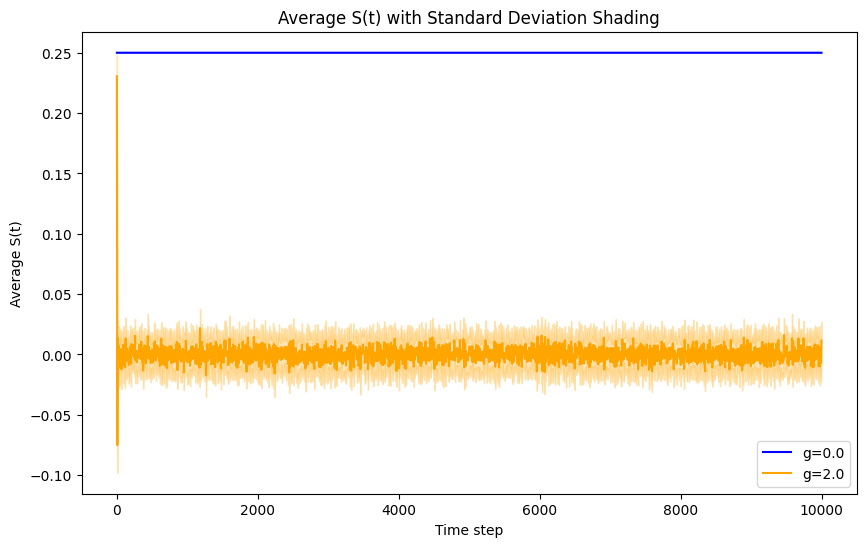

In [47]:
S_g0_avg = np.real(np.mean(S_g0[:, 1:], axis=0))
S_g2_avg = np.real(np.mean(S_g2[:, 1:], axis=0))

S_g0_std = np.real(np.std(S_g0[:, 1:], axis=0))
S_g2_std = np.real(np.std(S_g2[:, 1:], axis=0))

plt.figure(figsize=(10, 6))
plt.plot(S_g0_avg, label="g=0.0", color="blue")
plt.plot(S_g2_avg, label="g=2.0", color="orange")
plt.fill_between(range(len(S_g0_avg)), S_g0_avg - S_g0_std, S_g0_avg + S_g0_std, color="blue", alpha=0.3)
plt.fill_between(range(len(S_g2_avg)), S_g2_avg - S_g2_std, S_g2_avg + S_g2_std, color="orange", alpha=0.3)
plt.xlabel("Time step") 
plt.ylabel("Average S(t)")
plt.title("Average S(t) with Standard Deviation Shading")
plt.legend()
plt.show()

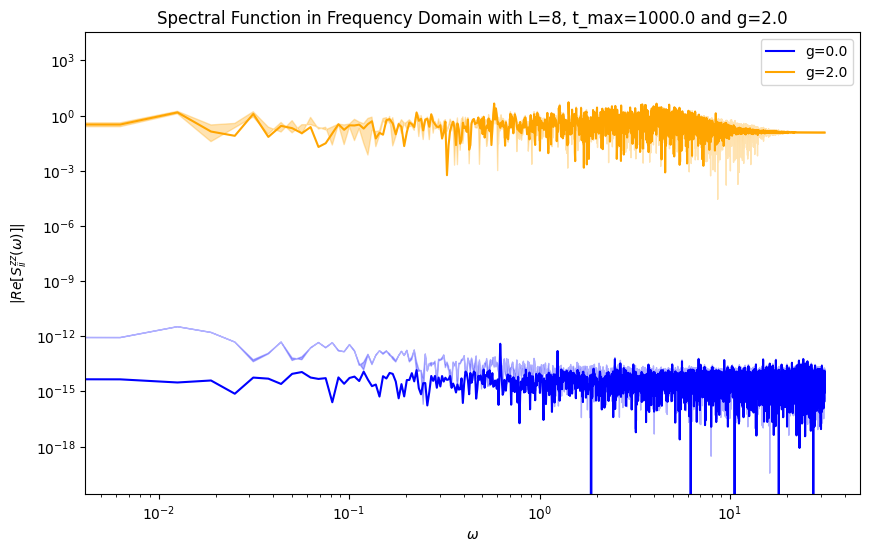

In [51]:
omega = 2 * np.pi * np.fft.fftshift(np.fft.fftfreq(N_t-1, d=dt))
S_g0_fft = np.real(
    np.fft.fftshift(np.fft.fft(S_g0_avg))
)
S_g2_fft = np.real(
    np.fft.fftshift(np.fft.fft(S_g2_avg))
)

S_g0_std_fft = np.real(
    np.fft.fftshift(np.fft.fft(S_g0_std))
)
S_g2_std_fft = np.real(
    np.fft.fftshift(np.fft.fft(S_g2_std))
)   


plt.figure(figsize=(10, 6))
plt.plot(omega, np.abs(S_g0_fft), label="g=0.0", color="blue")
plt.plot(omega, np.abs(S_g2_fft), label="g=2.0", color="orange")
plt.fill_between(omega, np.abs(S_g0_fft - S_g0_std_fft), np.abs(S_g0_fft + S_g0_std_fft), color="blue", alpha=0.3)
plt.fill_between(omega, np.abs(S_g2_fft - S_g2_std_fft), np.abs(S_g2_fft + S_g2_std_fft), color="orange", alpha=0.3)
plt.xlabel(r'$\omega$')
plt.ylabel(r'$|Re[S_{ii}^{zz}(\omega)]|$')
plt.title(r'Spectral Function in Frequency Domain with L={}, t_max={:.1f} and g={}'.format(L, t_max, g))
plt.xscale('log')
plt.yscale('log')
plt.legend()
plt.show()


In [53]:
min_size = min(s.shape[0] for s in S)
S = [s[:min_size] for s in S]
S = np.array(S)

S_avg = np.mean(S[:, :, 1:], axis=1) 
S_std = np.std(S[:, :, 1:], axis=1) 




omega = np.fft.fftshift(np.fft.fftfreq(len(S_avg[0, :]), d=dt)) * 2 * np.pi
S_omega = np.real(
    np.fft.fftshift(np.fft.fft(S_avg), axes=1)
    ) 
S_omega_std = np.real(
    np.fft.fftshift(np.fft.fft(S_std), axes=1)
    ) 

plt.figure(figsize=(8, 5))

for idx, J_val in enumerate([-1.0, -0.5, 0.0, 0.5, 1.0]):
     plt.plot(omega, np.abs(S_omega[idx, :]), label=f'J={J_val}', alpha=1.0)
     plt.fill_between(omega, np.abs(S_omega[idx, :]) - S_omega_std[idx, :], np.abs(S_omega[idx, :]) + S_omega_std[idx, :], alpha=0.1)   

plt.xlabel(r'$\omega$')
plt.ylabel(r'$|Re[S_{ii}^{zz}(\omega)]|$')
plt.title(r'Spectral Function in Frequency Domain with L={}, t_max={:.1f} and g={}'.format(L, t_max, g))
plt.xscale('log')
plt.yscale('log')
plt.legend()
plt.show()

NameError: name 'S' is not defined

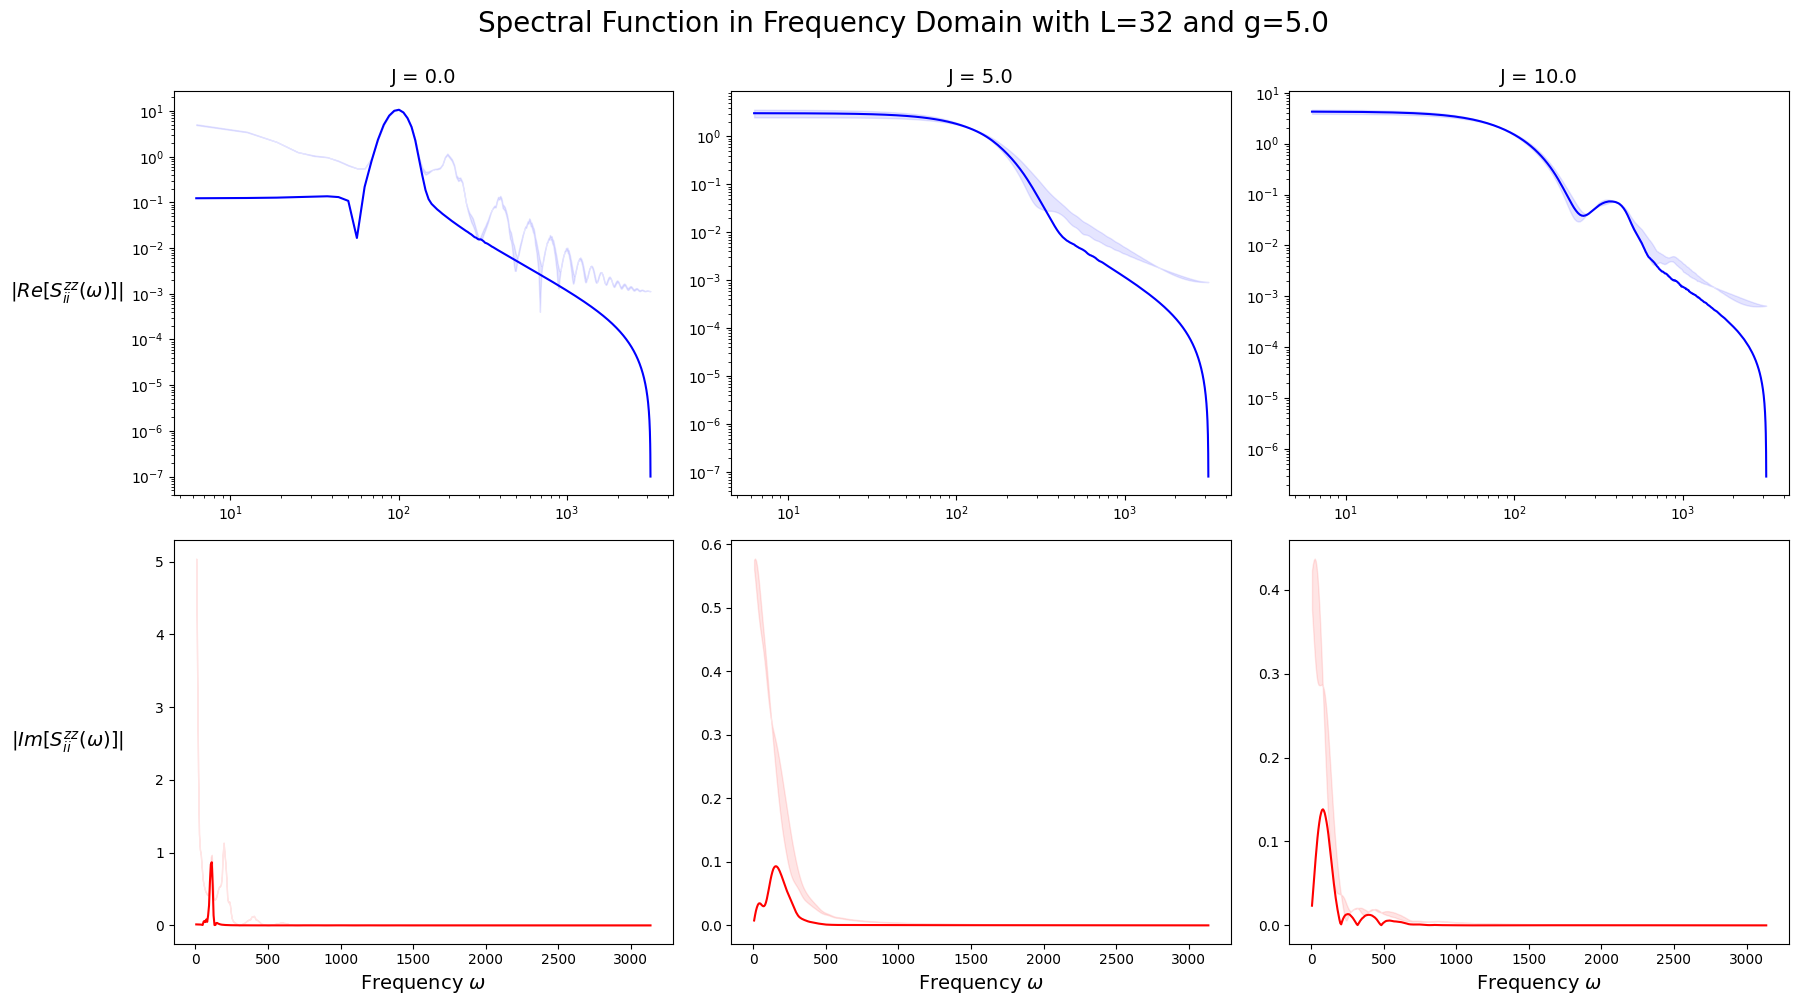

In [ ]:
# Define J values to plot
J_values = [0.0, 2.0, 5.0]

# Create figure with 2 rows (real and imaginary) and columns for each J value
fig, axes = plt.subplots(2, len(J_values), figsize=(6*len(J_values), 10))

# Add column labels at the top
for j_idx, J_val in enumerate(J_values):
    axes[0, j_idx].set_title(f'J = {J_val}', fontsize=14)

# Plot for each J value
for j_idx, J_val in enumerate(J_values):
    # Load data for this J value
    S_t_j = np.load(f'Results/S_L{L}_g{g}_J{J_val}.npy')
    S_t_j = S_t_j[:, 1:] 

    # Process data
    S_avg_j = np.mean(np.array(S_t_j), axis=0)
    S_avg_j = (S_avg_j + np.flip(S_avg_j)) / 2  # Symmetrize to reduce noise
    S_std_j = np.std(np.array(S_t_j), axis=0)
    
    omega_j = np.fft.fftshift(np.fft.fftfreq(len(S_avg_j), d=dt)) * 2 * np.pi
    S_omega_j = np.fft.fftshift(np.fft.fft(S_avg_j))
    S_omega_std_j = np.fft.fftshift(np.fft.fft(S_std_j))
    
    mask_j = (omega_j > 0)
    omega_j = omega_j[mask_j]
    S_omega_j = S_omega_j[mask_j]
    S_omega_std_j = S_omega_std_j[mask_j]

    # Plot Real part (row 0)
    ax_real = axes[0, j_idx]
    ax_real.plot(omega_j, np.abs(S_omega_j.real), color='blue', alpha=1.0)
    ax_real.fill_between(omega_j, np.abs(S_omega_j.real - S_omega_std_j), np.abs(S_omega_j.real + S_omega_std_j), alpha=0.1, color='blue')
    ax_real.set_xscale('log')
    ax_real.set_yscale('log')

    # Add row label on the left for the first column only
    if j_idx == 0:
        ax_real.text(-0.1, 0.5, r'$|Re[S_{ii}^{zz}(\omega)]|$', transform=ax_real.transAxes, 
                    fontsize=14, va='center', ha='right')
    
    # Plot Imaginary part (row 1)
    ax_imag = axes[1, j_idx]
    ax_imag.plot(omega_j, np.abs(S_omega_j.imag), color='red', alpha=1.0)
    ax_imag.fill_between(omega_j, np.abs(S_omega_j.imag - S_omega_std_j), np.abs(S_omega_j.imag + S_omega_std_j), alpha=0.1, color='red')
    ax_imag.set_xlabel(r'Frequency $\omega$', fontsize=14)

    # Add row label on the left for the first column only
    if j_idx == 0:
        ax_imag.text(-0.1, 0.5, r'$|Im[S_{ii}^{zz}(\omega)]|$', transform=ax_imag.transAxes, 
                    fontsize=14, va='center', ha='right')

fig.suptitle(f'Spectral Function in Frequency Domain with L={L} and g={g}', fontsize=20, y=1.0) 

plt.tight_layout()
plt.show()

